# 4장 분류

# 3. 앙상블 학습

### 3.1 앙상블 학습 개요

3.1.1 앙상블 학습: 다양한 분류기의 예측 결과를 결합 (단일 분류기보다 높은 예측값)
- 비정형 데이터(이미지, 영상 등): 딥러닝이 높은 성능 
- 정형 데이터: 랜덤 포레스트, 그래디언트 부스팅 알고리즘 등이 여전히 많이 사용됨
> 앙상블 학습: 보팅, 배깅, 부스팅
>> 랜덤 포레스트, 그래디언트 부스팅
>>> XGBoost, LightGBM

3.1.2 
1. 종류
- 보팅: 다른 알고리즘을 가진 분류기 결합
- 배깅: 같은 알고리즘을 가진 분류기 결합 + 데이터 샘플링을 서로 다르게 가짐 
> 배깅 ex. 랜덤 포레스트 알고리즘
- 부스팅: 순차적으로 분류기 학습 + 앞서 예측이 틀린 경우, 가중치를 부여
> 부스팅 ex. 그래디언트 부스트, XGBoost, LightGBM
- 스태킹: 여러 가지 다른 모델의 예측 결괏값을 다시 학습 데이터로 만들어서 다른 모델로 재학습시켜 결과를 예측하는 방법

2. 알고리즘에 따른 차이
- 보팅, 스태킹 : 다양한 알고리즘
- 배깅, 부스팅 : (일반적으로) 결정 트리 알고리즘으로 진행
> 다양한 상황을 학습 : 장점은 취하고 단점은 극복하며 편향-분산 트레이드오프의 효과를 극대화

### 3.2 보팅 유형 - 하드 보팅과 소프트 보팅

3.2.1 하드 보팅과 소프트 보팅
- 하드 보팅: 많이 나온 값으로
- 소프트 보팅: 모든 예측값들의 평균 or 확률들의 평균 중 높은 값
> 주로 소프트 보팅을 사용

### 3.3 실습_**보팅** 분류기
- 보팅의 정확도가 항상 높은 것은 아님

In [ ]:
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()
data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

In [ ]:
# 개별 모델은 로지스틱 회귀와 KNN임.
lr_clf = LogisticRegression(max_iter=10000)
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR', lr_clf), ('KNN', knn_clf)], voting='soft')

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

# VotingClassifier 학습/예측/평가.
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델의 학습/예측/평가.
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    class_name = classifier.__class__.__name__
    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

# 4. 배깅_랜덤 포레스트

### 4.1 배깅
- 배깅: 개별 트리가 학습하는 데이터 세트는 전체 데이터에서 일부가 중첩되게 샘플링된 데이터 세트
> 이름의 뜻 : Boostrap Aggerating = Bagging
- 랜덤 포레스트: 데이터가 중첩된 개별 데이터 세트에 결정 트리 분류기를 각각 적용

In [2]:
# 205pg 코드 가져오기

import pandas as pd

# [필수] 중복 피처명 해결을 위한 사전 함수
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(),
                                  columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(
        lambda x: x[0] + '_' + str(x[1]) if x[1] > 0 else x[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

# [메인] 데이터셋 로드 함수
def get_human_dataset():
    # 1. 피처명 파일 로드 및 중복 제거
    feature_name_df = pd.read_csv('./human_activity/features.txt', sep='\s+', 
                                  header=None, names=['column_index', 'column_name'])
    
    new_feature_name_df = get_new_feature_name_df(feature_name_df)
    
    # 데이터프레임의 컬럼명으로 쓰기 위해 리스트로 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()
    
    # 2. 학습/테스트 피처 데이터 로드 (sep='\s+' 주의)
    X_train = pd.read_csv('./human_activity/train/X_train.txt', sep='\s+', names=feature_name)
    X_test = pd.read_csv('./human_activity/test/X_test.txt', sep='\s+', names=feature_name)
    
    # 3. 학습/테스트 레이블(정답) 데이터 로드
    y_train = pd.read_csv('./human_activity/train/y_train.txt', sep='\s+', 
                          header=None, names=['action'])
    y_test = pd.read_csv('./human_activity/test/y_test.txt', sep='\s+', 
                         header=None, names=['action'])
    
    # 로드된 데이터프레임들을 반환
    return X_train, X_test, y_train, y_test

# 함수 실행 및 데이터 할당 (함수 밖에서 호출해야 함)
X_train, X_test, y_train, y_test = get_human_dataset()

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# 결정 트리에서 사용한 get_human_dataset()를 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=0)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)

print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9223


### 4.2 랜덤 포레스트 하이퍼 파라미터 및 튜닝

4.2.1 앙상블의 단점: 시간이 오래 걸림
- 그나마 랜덤 포레스트(배깅)가 다른 것들보다는 덜 걸림

4.2.2 하이퍼 파라미터 튜닝 _ GridSearhCV
- 최적의 하이퍼 파라미터를 구하기 

In [5]:
# Step1. 최적의 하이퍼 파라미터 구하기
from sklearn.model_selection import GridSearchCV

# 하이퍼 파라미터 설정 (오타 수정: n_estimators, 언더바 추가 등)
params = {
    'n_estimators': [100],
    'max_depth': [6, 8, 10, 12],
    'min_samples_leaf': [8, 12, 18],
    'min_samples_split': [8, 16, 20]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
# n_jobs=-1을 추가하면 모든 CPU 코어를 사용하여 속도가 빨라집니다.
rf_clf = RandomForestClassifier(random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 10, 'min_samples_leaf': 8, 'min_samples_split': 8, 'n_estimators': 100}
최고 예측 정확도: 0.9178


In [6]:
# Step2. 다시 RandomForestClassifier를 학습시킨 뒤에 별도의 테스트 데이터 세트에서 예측 성능 측정

# 하이퍼 파라미터를 설정하여 RandomForestClassifier 객체 생성
rf_clf1 = RandomForestClassifier(n_estimators=300, max_depth=10, min_samples_leaf=8,
                                 min_samples_split=8, random_state=0)

# 학습 및 예측
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)

# 결과 출력
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9165


In [ ]:
#Step3. 피처의 중요도 시각화
import matplotlib.pyplot as plt
import seaborn as sns
# 주피터 노트북 사용 시 그래프를 내부에 출력하기 위한 설정
%matplotlib inline

# 피처 중요도 값 가져오기
ftr_importances_values = rf_clf1.feature_importances_

# Series로 변환 (index는 X_train의 컬럼명)
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)

# 중요도 순으로 정렬 후 상위 20개만 추출
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

# 시각화 설정
plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.show()

# 5. 부스팅1_GBM(Gradient Boosting Machine)

### 5.1 GBM의 개요 및 실습

5.1.1 부스팅이란
- 여러 개의 약한 학습기를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식
> ex. AdaBoost, GBM

5.1.2 AdaBoost(Adaptive Boosting)
- 오류 데이터에 가중치를 부여하면서 부스팅을 수행하는 대표적인 알고리즘
- 단계별로 각각 가중치를 부여해 결합

5.1.3 GBM(Gradient Boost Machine)
- 가중치 업데이트를 경사 하강법을 이용
- **경사 하강법**: Loss(cost)가 최소가 되는 방향성을 가지고 반복적으로 가중치 값을 업데이트하는 방법
- 랜덤 포레스트보다는 나은 성능 / 시간은 오래, 하이퍼 파라미터 튜닝 노력도 더 필요

In [8]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

# 데이터 로드 (앞서 정의한 함수 사용)
X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위한 시작 시간 설정
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print("GBM 수행 시간: {0:.1f} 초".format(time.time() - start_time))

KeyboardInterrupt: 

### 5.2 GBM 하이퍼 파라미터 및 튜닝

In [ ]:
#Step1. 하이퍼 파라미터 튜닝 
from sklearn.model_selection import GridSearchCV

# 하이퍼 파라미터 설정 (오타 수정: n_estimators, 중괄호 등)
params = {
    'n_estimators': [100, 500],
    'learning_rate': [0.05, 0.1]
}

# GridSearchCV 수행
grid_cv = GridSearchCV(gb_clf, param_grid=params, cv=2, verbose=1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

In [ ]:
#Step2. 예측 정확도 확인
# GridSearchCV를 이용해 최적으로 학습된 estimator로 예측 수행
gb_pred = grid_cv.best_estimator_.predict(X_test)
gb_accuracy = accuracy_score(y_test, gb_pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))

# 6. XGBoost(extra Gradient Boost)

### 6.1 XGBoost 개요

6.1.1 장점
- GBM에 기반하지만, GBM의 단점인 느린 수행 시간 및 과적합 규제 부재 등의 문제를 해결
- 특히, XGBoost는 병렬 CPU 환경에서 병렬 학습이 가능해 기존 GBM보다 빠르게 학습 가능

6.1.2 종류
- 사이킷런 호환X : 파이썬 래퍼 XGBoost 모듈
- 사이킷런 호환O : 사이킷런 래퍼 XGBoost 모듈

In [1]:
import xgboost as xgb
from xgboost import XGBClassifier

### 6.2 파이썬 래퍼 XGBoost 하이퍼 파라미터

- 일반 파라미터: booster / silent / nthread
- 부스터 파라미터: eta / num_boost_rounds / min_child_weight / gamma / max_depth / sub_sample / colsample_bytree / lambda / alpha / scale_pos_weigh
- 태스크 파라미터: objective / binary:logistic: / multi:softmax: / mult:softprob: / eval_metric

### 6.3 파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측
- 악성 종양 vs 양성 종양 구분

In [2]:
#Step1. 데이터 뽑아내기
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings

warnings.filterwarnings('ignore')

# 데이터 로드 (괄호 추가)
dataset = load_breast_cancer()
X_features = dataset.data
y_label = dataset.target

# DataFrame 생성 및 타겟 컬럼 추가
cancer_df = pd.DataFrame(data=X_features, columns=dataset.feature_names)
cancer_df['target'] = y_label

# 데이터 확인: hear -> head로 수정
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


In [3]:
#Step2. 레이블로 정리
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


In [5]:
#Step3. train/test 구분
#전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2, random_state=156)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


In [18]:
#Step4. DMatrix를 생성 (특이한 점)
#Dmatrix: 넘파이 입력 파라미터를 받아서 만들어지는 XGBoost만의 전용 데이터 세트 
#주요 입력 파라미터: data(피처 데이터 세트) / label(레이블 데이터 세트 / 숫자형 종속값 데이터 세트)

dtrain = xgb.DMatrix(data=X_train, label=y_train)
dtest = xgb.DMatrix(data=X_test, label=y_test)

In [19]:
#Step5. 하이퍼 파라미터 설정
params = {'max_depth':3,
          'eta':0.1,
          'objective':'binary:logistic',
          'eval_metric':'logloss',
          'early_stoppings':100}
num_rounds = 400

In [20]:
#Step6. XGBoost를 학습
#평가와 조기 중단을 통해서 더 이상의 수행력 향상이 없다면 중단을 외치게 함
# train 데이터 세트는 'train', evaluation(test) 데이터 세트는 'eval'로 명기합니다.
wlist = [(dtrain, 'train'), (dtest, 'eval')]

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달
xgb_model = xgb.train(params=params, dtrain=dtrain, num_boost_round=num_rounds, \
                      early_stopping_rounds=100, evals=wlist)

[0]	train-logloss:0.58417	eval-logloss:0.56499
[1]	train-logloss:0.51864	eval-logloss:0.50615
[2]	train-logloss:0.46435	eval-logloss:0.45818
[3]	train-logloss:0.41691	eval-logloss:0.41774
[4]	train-logloss:0.37564	eval-logloss:0.38060
[5]	train-logloss:0.34054	eval-logloss:0.35098
[6]	train-logloss:0.31009	eval-logloss:0.32552
[7]	train-logloss:0.28265	eval-logloss:0.30095
[8]	train-logloss:0.25909	eval-logloss:0.28167
[9]	train-logloss:0.23807	eval-logloss:0.26239
[10]	train-logloss:0.21937	eval-logloss:0.24797
[11]	train-logloss:0.20238	eval-logloss:0.23210
[12]	train-logloss:0.18748	eval-logloss:0.22060
[13]	train-logloss:0.17376	eval-logloss:0.20778
[14]	train-logloss:0.16181	eval-logloss:0.19775
[15]	train-logloss:0.15094	eval-logloss:0.18975
[16]	train-logloss:0.14116	eval-logloss:0.18064
[17]	train-logloss:0.13156	eval-logloss:0.17250
[18]	train-logloss:0.12323	eval-logloss:0.16517
[19]	train-logloss:0.11561	eval-logloss:0.15833
[20]	train-logloss:0.10858	eval-logloss:0.15442
[2

In [22]:
#Step7. 테스트 데이터 세트에 예측을 수행
# predict()를 사용 >> 예측값이 아닌 예측 결과를 추정할 수 있는 확률 값을 반환
# 즉, 악성인지 양성인지 판단하는 이진 분류이므로 예측 확률이 0.5보다 크면 1/ 0.5보자 작으면 0으로 예측 값을결정하는 로직을 추가

# 1. 변수명 통일 (pred_probs)
pred_probs = xgb_model.predict(dtest)

print('predict() 수행 결과값을 10개만 표시, 예측 확률값으로 표시됨')
# 2. predprobs -> pred_probs / [probs: 10] -> [:10] 오타 수정
print(np.round(pred_probs[:10], 3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측값 결정해 리스트 객체인 preds에 저장
# 3. predprobs -> pred_probs 변수명 수정
preds = [1 if x > 0.5 else 0 for x in pred_probs]

# 4. [:101) -> [:10] 괄호 및 오타 수정
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결과값을 10개만 표시, 예측 확률값으로 표시됨
[0.892 0.003 0.888 0.181 0.989 1.    1.    0.999 0.996 0.   ]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


In [25]:
#Step8. XGBoost 모델의 예측 성능을 평가
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def get_clf_eval(y_test, pred):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    
    print('오차 행렬')
    print(confusion)
    # .format() 끝에 recall을 꼭 추가해 주세요!
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}'.format(accuracy, precision, recall))

get_clf_eval(y_test, preds)

오차 행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

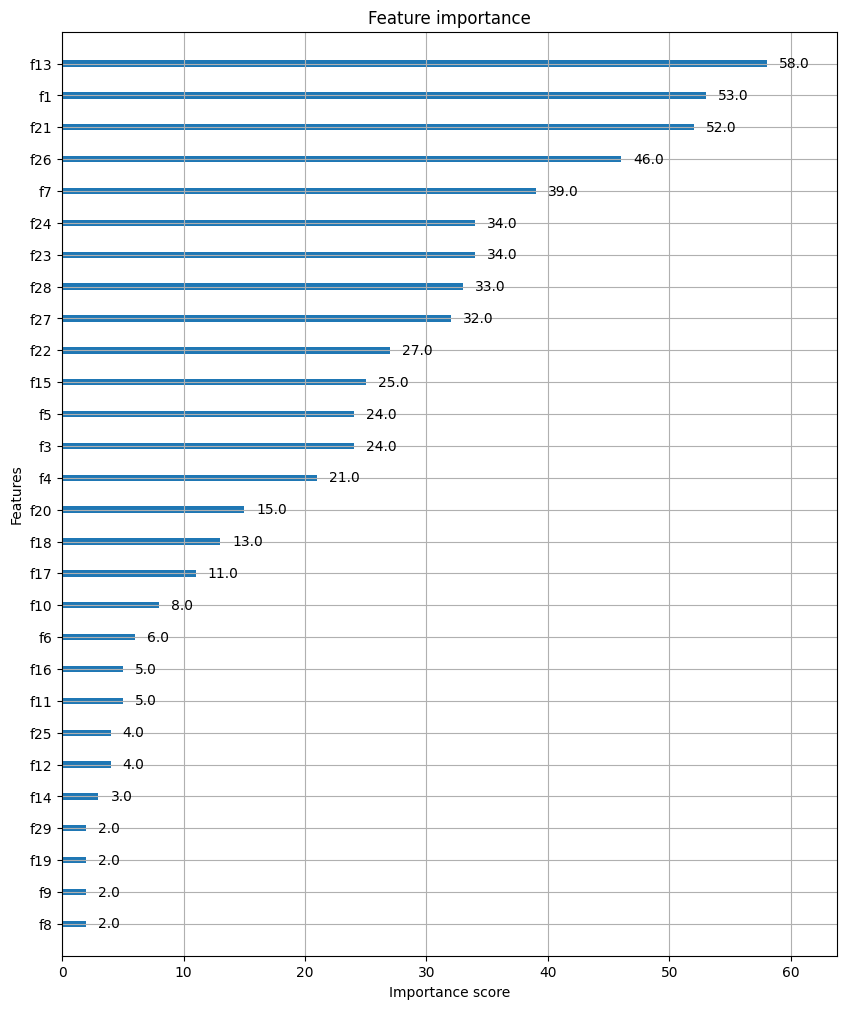

In [26]:
#Step9. 피처 중요도 시각화
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)

### 6.4 사이킷런 래퍼 XGBoost의 개요 및 적용
- 파이썬 래퍼와는 달리 사이킷런의 기본 유틸리티를 모두 사용 가능
- 분류: XGBClassifier / 회귀: XGBRegressor
- 주의) 따라서 네이티브 하아퍼 파라미터 몇 개를 변경해야 하는 경우도 있음

In [28]:
#Step1. 데이터 세트 분류, 학습 및 예측을 수행
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# 1. xb_wrapper -> xgb_wrapper로 통일, n_estimators=400 (= 사용)
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3)

xgb_wrapper.fit(X_train, y_train)

w_preds = xgb_wrapper.predict(X_test)

w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [30]:
#Step2. 성능 평가
get_clf_eval(y_test, w_preds)

오차 행렬
[[35  2]
 [ 1 76]]
정확도: 0.9737, 정밀도: 0.9744, 재현율: 0.9870


In [32]:
#Step3. 조기 중단 기능 적용
from xgboost import XGBClassifier

# 최신 XGBoost 버전에서는 early_stopping_rounds와 eval_metric을 생성자(XGBClassifier)에 작성해야 합니다.
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, 
                            early_stopping_rounds=100, eval_metric="logloss")

evals = [(X_test, y_test)]

xgb_wrapper.fit(X_train, y_train, eval_set=evals, verbose=True)

ws100_preds = xgb_wrapper.predict(X_test)
ws100_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

[0]	validation_0-logloss:0.56499
[1]	validation_0-logloss:0.50615
[2]	validation_0-logloss:0.45818
[3]	validation_0-logloss:0.41774
[4]	validation_0-logloss:0.38060
[5]	validation_0-logloss:0.35098
[6]	validation_0-logloss:0.32552
[7]	validation_0-logloss:0.30095
[8]	validation_0-logloss:0.28167
[9]	validation_0-logloss:0.26239
[10]	validation_0-logloss:0.24797
[11]	validation_0-logloss:0.23210
[12]	validation_0-logloss:0.22060
[13]	validation_0-logloss:0.20778
[14]	validation_0-logloss:0.19775
[15]	validation_0-logloss:0.18975
[16]	validation_0-logloss:0.18064
[17]	validation_0-logloss:0.17250
[18]	validation_0-logloss:0.16517
[19]	validation_0-logloss:0.15833
[20]	validation_0-logloss:0.15442
[21]	validation_0-logloss:0.14640
[22]	validation_0-logloss:0.13943
[23]	validation_0-logloss:0.13421
[24]	validation_0-logloss:0.13041
[25]	validation_0-logloss:0.12705
[26]	validation_0-logloss:0.12288
[27]	validation_0-logloss:0.11970
[28]	validation_0-logloss:0.11748
[29]	validation_0-loglos

In [34]:
#Step4. 조기 중단 적용한 경우의 성능 확인 
get_clf_eval(y_test, ws100_preds)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870


In [36]:
#Step5. 조기 중단이 너무 이르게 되는 것을 방지
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.1, max_depth=3, 
                            early_stopping_rounds=10, eval_metric="logloss")

evals = [(X_test, y_test)]
xgb_wrapper.fit(X_train, y_train, eval_set=evals, verbose=True)

ws10_preds = xgb_wrapper.predict(X_test)
ws10_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]
get_clf_eval(y_test, ws10_preds)

[0]	validation_0-logloss:0.56499
[1]	validation_0-logloss:0.50615
[2]	validation_0-logloss:0.45818
[3]	validation_0-logloss:0.41774
[4]	validation_0-logloss:0.38060
[5]	validation_0-logloss:0.35098
[6]	validation_0-logloss:0.32552
[7]	validation_0-logloss:0.30095
[8]	validation_0-logloss:0.28167
[9]	validation_0-logloss:0.26239
[10]	validation_0-logloss:0.24797
[11]	validation_0-logloss:0.23210
[12]	validation_0-logloss:0.22060
[13]	validation_0-logloss:0.20778
[14]	validation_0-logloss:0.19775
[15]	validation_0-logloss:0.18975
[16]	validation_0-logloss:0.18064
[17]	validation_0-logloss:0.17250
[18]	validation_0-logloss:0.16517
[19]	validation_0-logloss:0.15833
[20]	validation_0-logloss:0.15442
[21]	validation_0-logloss:0.14640
[22]	validation_0-logloss:0.13943
[23]	validation_0-logloss:0.13421
[24]	validation_0-logloss:0.13041
[25]	validation_0-logloss:0.12705
[26]	validation_0-logloss:0.12288
[27]	validation_0-logloss:0.11970
[28]	validation_0-logloss:0.11748
[29]	validation_0-loglos

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

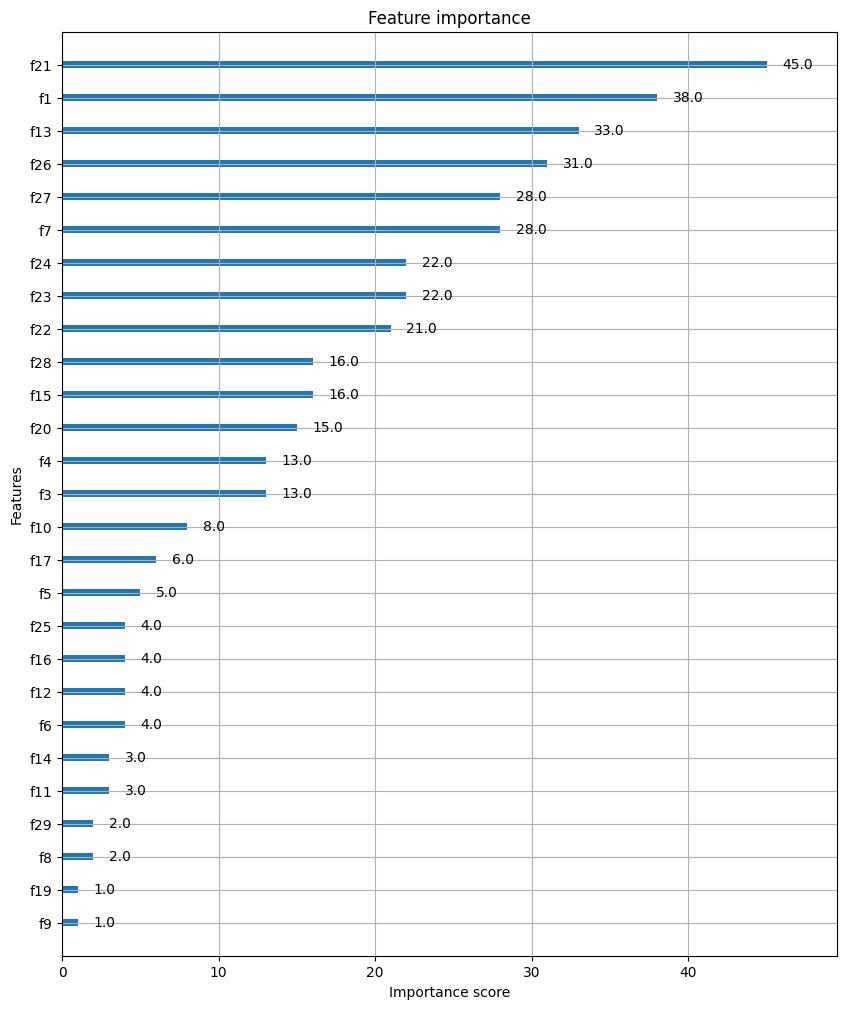

In [37]:
#Step6. 피처 중요도 시각화
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10,12))
#사이킷런 Wrapper 클래스를 입력해도 무방.
plot_importance(xgb_wrapper, ax=ax)

# 7. LightGBM

### 7.1 LightGBM 개요

#### 7.1.1 특징
- 장점: XGBoost의 경우 긴 학습 시간에 비해서 시간이 덜 소모 / 메모리 사용량이 상대적으로 적다
- 단점: light이기에 정밀도가 떨어진다? NO 실제로 떨어지지도 않음

#### 7.1.2 분할 방법
1. GBM 계열: 트리 분할 방법 
> 과적합을 방지하기 위해 균형을 맞추기 위한 시간에 할애
2. LightGBM:리프 중심 트리 분할(Leaf Wise)방식 
- 최대 손실값을 가지는 리프 노드를 지속적으로 분할하면서 트리의 깊이가 깊어지고 비대칭적인 규칙 트리가 생성
- 학습을 반복할수록 균형 트리 분할 방식보다 예측 오류 손실을 최소화

# 7.2 LightGBM 하이퍼 파라미터

### 7.2.1 파라미터
- 주의사항: 트리의 깊이가 깊어지므로 이러한 트리 특성에 맞는 하이퍼 파라미터 설정이 필요함
1. 주요 파라미터 
2. Learning Task 파라미터

### 7.2.2 하이퍼 파라미터 튜닝 방안
1. num_leaves의 개수를 중심으로 min_child_samples, max_depth를 함께 조정하며 모델의 복잡도를 줄이는 것이 기본 튜닝 방안
2. learning_rate을 작게 하면서 n_estimator를 크게 하기
3. regulation(reg_lambda, reg_alpha)을 적용
4. 학습 데이터에 사용할 피처의 개수나 데이터 샘플링 레코드 개수를 줄이기(colsample_bytree, subsample)

### 7.3 LightGBM 적용 - 위스콘신 유방암 예측

In [1]:
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 데이터 로드
dataset = load_breast_cancer()
ftr = dataset.data
target = dataset.target

# 학습/테스트 데이터 세트 분리
X_train, X_test, y_train, y_test = train_test_split(ftr, target, test_size=0.2, random_state=156)

# LightGBM 모델 생성
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05)

# 조기 중단(Early Stopping) 설정 및 학습
evals = [(X_test, y_test)]
lgbm_wrapper.fit(X_train, y_train, 
                 eval_set=evals, 
                 eval_metric="logloss",
                 callbacks=[early_stopping(stopping_rounds=100), 
                            log_evaluation(period=10)])

# 예측 수행
preds = lgbm_wrapper.predict(X_test)
pred_proba = lgbm_wrapper.predict_proba(X_test)[:, 1]

[LightGBM] [Info] Number of positive: 280, number of negative: 175
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000253 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4542
[LightGBM] [Info] Number of data points in the train set: 455, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.615385 -> initscore=0.470004
[LightGBM] [Info] Start training from score 0.470004
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 100 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

C:\Users\chb12\anaconda3\envs\pf\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chb12\anaconda3\envs\pf\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [5]:
get_clf_eval(y_test, preds)

오차 행렬
[[33  4]
 [ 1 76]]
정확도: 0.9561, 정밀도: 0.9500, 재현율: 0.9870


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

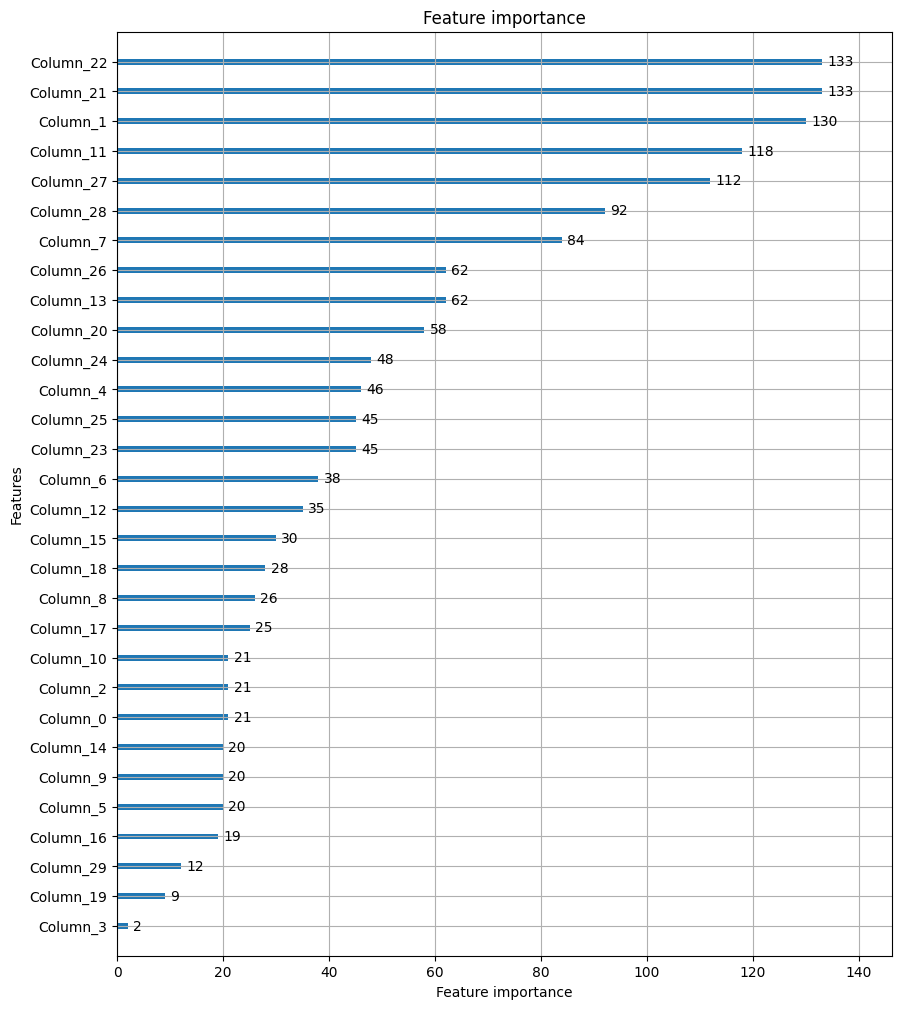

In [6]:
%matplotlib inline
from lightgbm import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)

# 8. 분류 실습 - 캐글 산탄데르 고객 만족 예측

### 8.1 데이터 전처리

In [4]:
#Step1. 데이터 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cust_df = pd.read_csv("train_santander.csv", encoding='latin-1')
print('dataset shape:', cust_df.shape)
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [5]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [6]:
#Step2. 만족/불만족 비율
print(cust_df['TARGET'].value_counts())
unsatisfied_cnt = cust_df[cust_df['TARGET'] == 1].TARGET.count()
total_cnt = cust_df.TARGET.count()
print('unsatisfied ratio {0:.2f}'.format((unsatisfied_cnt / total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied ratio 0.04


In [7]:
#Step3. 피처의 분포
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


In [10]:
#Step4. ID 피처 드롭 및 클래스/피처 세트 분리
cust_df['var3'].replace(-999999, 2, inplace=True)
cust_df.drop('ID', axis=1, inplace=True)

# 피처 세트와 레이블 세트 분리. 레이블 칼럼은 DataFrame의 맨 마지막에 위치해 칼럼 위치 -1로 분리
X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]

print('피처 데이터 shape: {0}'.format(X_features.shape))

피처 데이터 shape: (76020, 369)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23140\2163855299.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cust_df['var3'].replace(-999999, 2, inplace=True)


In [11]:
#Step5. 학습/평가 데이터 분리 및 비대칭 데이터에 따른 값 분포도
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.2, random_state=0)

train_cnt = y_train.count()
test_cnt = y_test.count()

print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape, X_test.shape))
print('학습 세트 레이블 값 분포 비율')
print(y_train.value_counts() / train_cnt)
print('\n테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts() / test_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64

테스트 세트 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


### 8.2 XGBoost 모델 학습과 하이퍼 파라미터 튜닝

In [12]:
#Step1. 모델 학습 및 평가 (ROC AUC)
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# early_stopping_rounds와 eval_metric을 XGBClassifier 생성자(Constructor)로 이동
xgb_clf = XGBClassifier(n_estimators=500, random_state=156, 
                        early_stopping_rounds=100, eval_metric="auc")

# fit()에서는 eval_set만 지정
xgb_clf.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84292	validation_1-auc:0.82682
[1]	validation_0-auc:0.85114	validation_1-auc:0.83389
[2]	validation_0-auc:0.85699	validation_1-auc:0.83338
[3]	validation_0-auc:0.86184	validation_1-auc:0.83388
[4]	validation_0-auc:0.86530	validation_1-auc:0.83431
[5]	validation_0-auc:0.86753	validation_1-auc:0.83589
[6]	validation_0-auc:0.86959	validation_1-auc:0.83574
[7]	validation_0-auc:0.87163	validation_1-auc:0.83720
[8]	validation_0-auc:0.87353	validation_1-auc:0.83733
[9]	validation_0-auc:0.87515	validation_1-auc:0.83686
[10]	validation_0-auc:0.87762	validation_1-auc:0.83738
[11]	validation_0-auc:0.88011	validation_1-auc:0.83688
[12]	validation_0-auc:0.88076	validation_1-auc:0.83668
[13]	validation_0-auc:0.88183	validation_1-auc:0.83676
[14]	validation_0-auc:0.88251	validation_1-auc:0.83719
[15]	validation_0-auc:0.88462	validation_1-auc:0.83709
[16]	validation_0-auc:0.88706	validation_1-auc:0.83674
[17]	validation_0-auc:0.88736	validation_1-auc:0.83696
[18]	validation_0-au

In [13]:
#Step2. 하이퍼 파라미터 파인튜닝(1)
from sklearn.model_selection import GridSearchCV

# 하이퍼 파라미터 테스트의 수행 속도를 향상시키기 위해 n_estimators를 100으로 설정
# 이전 TypeError를 방지하기 위해 early_stopping_rounds와 eval_metric을 생성자에 설정
xgb_clf = XGBClassifier(n_estimators=100, random_state=156, 
                        early_stopping_rounds=30, eval_metric="auc")

params = {'max_depth': [5, 7], 'min_child_weight': [1, 3], 'colsample_bytree': [0.5, 0.75]}

# cv는 3으로 지정
grid_cv = GridSearchCV(xgb_clf, param_grid=params, cv=3)
grid_cv.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

print('GridSearchCV 최적 파라미터:', grid_cv.best_params_)

xgb_roc_score = roc_auc_score(y_test, grid_cv.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.74526	validation_1-auc:0.75000
[1]	validation_0-auc:0.81879	validation_1-auc:0.81570
[2]	validation_0-auc:0.83092	validation_1-auc:0.82677
[3]	validation_0-auc:0.83622	validation_1-auc:0.82960
[4]	validation_0-auc:0.84313	validation_1-auc:0.83311
[5]	validation_0-auc:0.84425	validation_1-auc:0.83505
[6]	validation_0-auc:0.84808	validation_1-auc:0.83692
[7]	validation_0-auc:0.84998	validation_1-auc:0.83741
[8]	validation_0-auc:0.85163	validation_1-auc:0.83864
[9]	validation_0-auc:0.85418	validation_1-auc:0.83885
[10]	validation_0-auc:0.85660	validation_1-auc:0.83837
[11]	validation_0-auc:0.85728	validation_1-auc:0.83897
[12]	validation_0-auc:0.85806	validation_1-auc:0.83917
[13]	validation_0-auc:0.85890	validation_1-auc:0.83910
[14]	validation_0-auc:0.85917	validation_1-auc:0.83879
[15]	validation_0-auc:0.86079	validation_1-auc:0.83904
[16]	validation_0-auc:0.86156	validation_1-auc:0.83859
[17]	validation_0-auc:0.86247	validation_1-auc:0.83938
[18]	validation_0-au

In [14]:
#Step2. 하이퍼 파라미터 파인튜닝(2) _ 다른 파라미터
# n_estimators는 1000으로 증가시키고, learning_rate=0.02로 감소, reg_alpha=0.03으로 추가함.
# TypeError 방지를 위해 early_stopping_rounds와 eval_metric을 생성자에 설정
xgb_clf = XGBClassifier(n_estimators=1000, random_state=156, learning_rate=0.02, 
                        max_depth=7, min_child_weight=1, colsample_bytree=0.75, 
                        reg_alpha=0.03, early_stopping_rounds=200, eval_metric="auc")

# 성능 평가 지표와 조기 중단 설정이 생성자에서 이루어졌으므로 eval_set만 지정하여 학습 수행.
xgb_clf.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)])

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.76930	validation_1-auc:0.75992
[1]	validation_0-auc:0.84377	validation_1-auc:0.82910
[2]	validation_0-auc:0.84947	validation_1-auc:0.83171
[3]	validation_0-auc:0.85569	validation_1-auc:0.83891
[4]	validation_0-auc:0.85894	validation_1-auc:0.83957
[5]	validation_0-auc:0.85729	validation_1-auc:0.83837
[6]	validation_0-auc:0.85918	validation_1-auc:0.83907
[7]	validation_0-auc:0.86083	validation_1-auc:0.84156
[8]	validation_0-auc:0.86186	validation_1-auc:0.84176
[9]	validation_0-auc:0.86041	validation_1-auc:0.84054
[10]	validation_0-auc:0.86244	validation_1-auc:0.84127
[11]	validation_0-auc:0.86380	validation_1-auc:0.84170
[12]	validation_0-auc:0.86495	validation_1-auc:0.84209
[13]	validation_0-auc:0.86558	validation_1-auc:0.84259
[14]	validation_0-auc:0.86577	validation_1-auc:0.84276
[15]	validation_0-auc:0.86676	validation_1-auc:0.84280
[16]	validation_0-auc:0.86625	validation_1-auc:0.84279
[17]	validation_0-auc:0.86623	validation_1-auc:0.84219
[18]	validation_0-au

In [ ]:
#Step3. 피처 중요도 시각화
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(xgb_clf, ax=ax, max_num_features=20, height=0.4)

### 8.3 LightGBM 모델 학습과 하이퍼 파라미터 튜닝

In [16]:
#Step1. 학습 및 평가
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# early_stopping_rounds를 생성자(Constructor)로 이동
lgbm_clf = LGBMClassifier(n_estimators=500, early_stopping_rounds=100)
evals = [(X_test, y_test)]

# fit()에서 early_stopping_rounds와 verbose 파라미터 제거
lgbm_clf.fit(X_train, y_train, eval_metric="auc", eval_set=evals)

lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 2374, number of negative: 58442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 14308
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 251
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039036 -> initscore=-3.203459
[LightGBM] [Info] Start training from score -3.203459
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[15]	valid_0's auc: 0.840928	valid_0's binary_logloss: 0.14161
ROC AUC

In [17]:
#Step2. 파라미터 튜닝
from sklearn.model_selection import GridSearchCV

# 하이퍼 파라미터 테스트의 수행 속도를 향상시키기 위해 n_estimators를 200으로 설정
# 최신 버전 호환성을 위해 early_stopping_rounds를 생성자에 설정
lgbm_clf = LGBMClassifier(n_estimators=200, early_stopping_rounds=30)

params = {
    'num_leaves': [32, 64],
    'max_depth': [128, 160],
    'min_child_samples': [60, 100],
    'subsample': [0.8, 1]
}

# cv는 3으로 지정
gridcv = GridSearchCV(lgbm_clf, param_grid=params, cv=3)
gridcv.fit(X_train, y_train, eval_metric="auc", eval_set=[(X_train, y_train), (X_test, y_test)])

print('GridSearchCV 최적 파라미터:', gridcv.best_params_)

lgbm_roc_score = roc_auc_score(y_test, gridcv.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] early_stopping_round is set=30, early_stopping_rounds=30 will be ignored. Current value: early_stopping_round=30
[LightGBM] [Info] Number of positive: 1583, number of negative: 38961
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010562 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12926
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 203
[LightGBM] [Warning] early_stopping_round is set=30, early_stopping_rounds=30 will be ignored. Current value: early_stopping_round=30
[LightGBM] [Warning] early_stopping_round is set=30, early_stopping_rounds=30 will be ignored. Current value: early_stopping_round=30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039044 -> initscore=-3.203239
[LightGBM] [Info] Start training from score -3.203239
Training until validation scores don't 

In [18]:
#Step3. 다시 평가
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

# early_stopping_rounds를 생성자에 설정하여 TypeError 방지
lgbm_clf = LGBMClassifier(n_estimators=1000, num_leaves=32, subsample=0.8, 
                          min_child_samples=100, max_depth=128, early_stopping_rounds=100)

evals = [(X_test, y_test)]

# fit()에서 early_stopping_rounds 및 verbose 제거
lgbm_clf.fit(X_train, y_train, eval_metric="auc", eval_set=evals)

lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1], average='macro')
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 2374, number of negative: 58442
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.016556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13851
[LightGBM] [Info] Number of data points in the train set: 60816, number of used features: 202
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.039036 -> initscore=-3.203459
[LightGBM] [Info] Start training from score -3.203459
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[11]	valid_0's auc: 0.841659	valid_0's binary_logloss: 0.14327
ROC AUC